In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

c:\Users\sheic\Documents\CISC483\CISC483-EngageTactics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Download YT Data
yt_path= kagglehub.dataset_download("bsthere/youtube-trending-videos-stats-2026")

print("Path to YouTube dataset files:", yt_path)

Path to YouTube dataset files: C:\Users\sheic\.cache\kagglehub\datasets\bsthere\youtube-trending-videos-stats-2026\versions\3


In [4]:
## Import US and Canadian YouTube Data
yt_df = pd.read_csv(yt_path + "/US_trending.csv")
yt_ca_df = pd.read_csv(yt_path + "/CA_trending.csv")

yt_df = pd.concat([yt_df, yt_ca_df], ignore_index=True)
del yt_ca_df
print(yt_df.info())
print(yt_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 32600 entries, 0 to 32599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       32600 non-null  str  
 1   trending_date  32600 non-null  str  
 2   title          32600 non-null  str  
 3   channel_title  32598 non-null  str  
 4   views          32600 non-null  int64
 5   likes          32600 non-null  int64
 6   dislikes       32600 non-null  int64
 7   publish_time   32600 non-null  str  
 8   category_id    32600 non-null  int64
 9   tags           32600 non-null  str  
 10  comments       32600 non-null  int64
 11  channel_id     32600 non-null  str  
 12  description    27433 non-null  str  
dtypes: int64(5), str(8)
memory usage: 3.2 MB
None
      video_id trending_date  \
0  5Q_sCOFwC5g      26.26.02   
1  b24oG7qCwp4      26.26.02   
2  e0ii_btaNWs      26.26.02   
3  iAtoZar5W58      26.26.02   
4  qtZeYpjJHi8      26.26.02   

                            

In [10]:
# time data

yt_df["publish_time"] = pd.to_datetime(yt_df["publish_time"], utc=True)
yt_df["days_since_upload"] = (pd.Timestamp.now(tz="UTC") - yt_df["publish_time"]).dt.days

print("Verify days since upload succeeded: ")
print(yt_df["days_since_upload"].head())
print("-------------------------")
print("Max days since upload: ", yt_df["days_since_upload"].max())
print("Min days since upload: ", yt_df["days_since_upload"].min())
print("Median days since upload: ", yt_df["days_since_upload"].median())
print("Mean days since upload: ", yt_df["days_since_upload"].mean())
print("Standard deviation of days since upload: ", yt_df["days_since_upload"].std())

Verify days since upload succeeded: 
0    76
1    76
2    75
3    77
4    76
Name: days_since_upload, dtype: int64
-------------------------
Max days since upload:  6971
Min days since upload:  75
Median days since upload:  251.0
Mean days since upload:  516.853435582822
Standard deviation of days since upload:  802.6431170987713


Text(0.5, 1.0, 'Views over time')

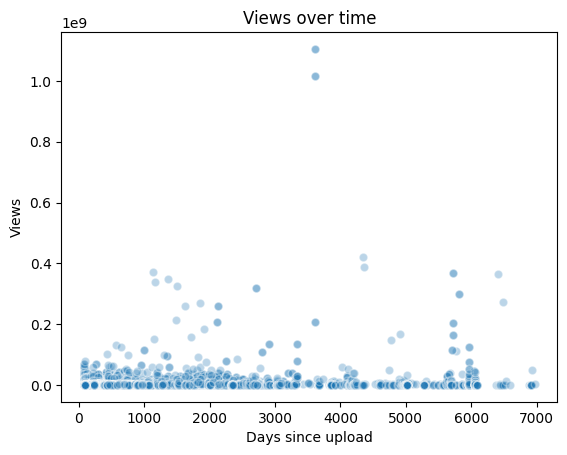

In [62]:
plt.scatter(yt_df["days_since_upload"], yt_df['views'], alpha=0.3, edgecolors="white")
plt.xlabel("Days since upload")
plt.ylabel("Views")
plt.title("Views over time")

Upper Quartile:  1045241.25
Lower Quartile:  47960.5
Inter-quartile Range:  997280.75
Median:  177947.0
Mean:  423420.2141036533
Upper limit (no outliers):  2539568


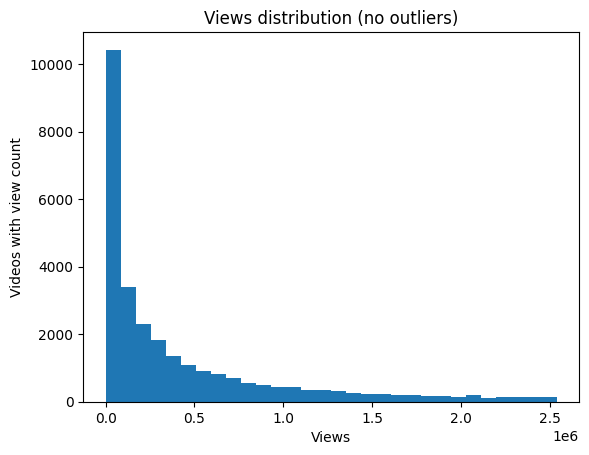

In [13]:
# Views distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['views'], [75, 25])
iqr = q75 - q25


no_outliers = yt_df[yt_df['views'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['views'] > (q25 - iqr*1.5)]

## Print Stats
print("Upper Quartile: ", q75)
print("Lower Quartile: ", q25)
print("Inter-quartile Range: ", iqr)
print("Median: ", no_outliers['views'].median())
print("Mean: ", no_outliers['views'].mean())
print("Upper limit (no outliers): ", no_outliers['views'].max())

plt.hist(no_outliers['views'], bins=30)
plt.title("Views distribution (no outliers)")
plt.ylabel("Videos with view count")
plt.xlabel("Views")
plt.show()

Max days since upload:  6971
Min days since upload:  75
Median days since upload:  244.0
Mean days since upload:  458.9920693928129
Standard deviation of days since upload:  694.7889887771071


Text(0.5, 1.0, 'Views over time')

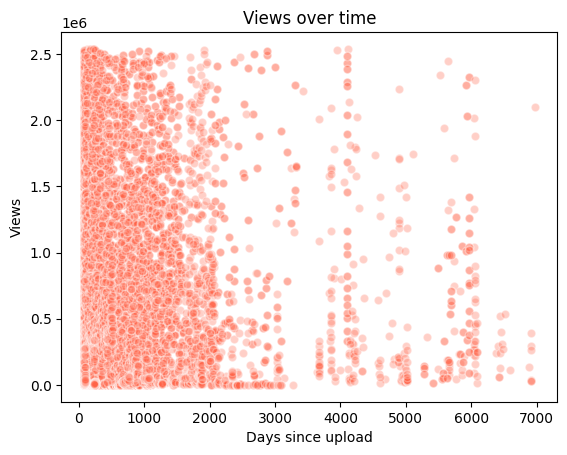

In [61]:
## Views with respect to time (Excluding outliers)
print("Max days since upload: ", no_outliers["days_since_upload"].max())
print("Min days since upload: ", no_outliers["days_since_upload"].min())
print("Median days since upload: ", no_outliers["days_since_upload"].median())
print("Mean days since upload: ", no_outliers["days_since_upload"].mean())
print("Standard deviation of days since upload: ", no_outliers["days_since_upload"].std())

plt.scatter(no_outliers["days_since_upload"], no_outliers['views'], c="tomato", alpha=0.3, edgecolors="white")
plt.xlabel("Days since upload")
plt.ylabel("Views")
plt.title("Views over time")

Text(0.5, 1.0, 'Excluding Outliers')

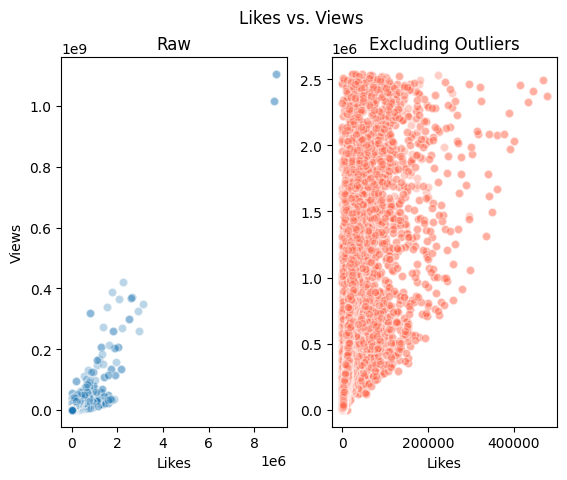

In [22]:
## Likes vs views

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Likes vs. Views")
ax1.scatter(yt_df["likes"], yt_df["views"], alpha=0.3, edgecolors="white")
ax1.set(xlabel="Likes", ylabel="Views")
ax1.set_title("Raw")
ax2.scatter(no_outliers["likes"], no_outliers["views"], c="tomato", alpha=0.3, edgecolors="white")
ax2.set(xlabel="Likes")
ax2.set_title("Excluding Outliers")

In [34]:
def print_stats(df_column):
    print("   Max: ", df_column.max())
    print("   Min: ", df_column.min())
    print("   Median: ", df_column.median())
    print("   Mean: ", df_column.mean())
    print("   Standard Dev: ", df_column.std())

------ Views per day --------
Raw: 
   Max:  872238.925
   Min:  0.0
   Median:  847.7818181818182
   Mean:  7162.504409724796
   Standard Dev:  28017.305559751123
No outliers: 
   Max:  32459.675324675325
   Min:  0.0
   Median:  613.5960264900663
   Mean:  2185.6237646061363
   Standard Dev:  4253.254653542686


Text(0.5, 1.0, 'No outliers')

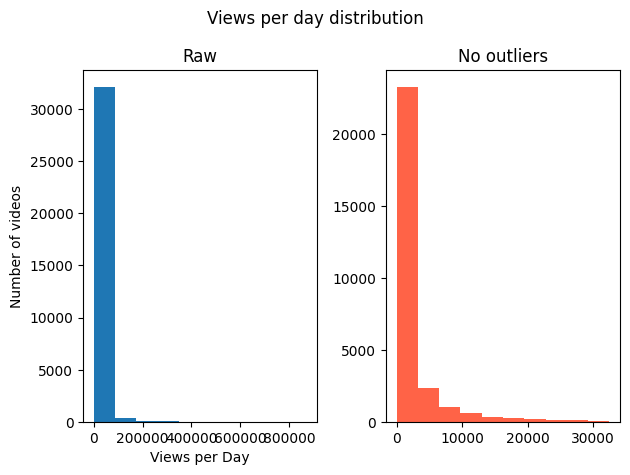

In [60]:
## Experimenting with success metrics
yt_df["views_per_day"] = yt_df["views"] / yt_df["days_since_upload"]

## Like/View ratio, replacing infinite values with 0
yt_df["likes_view_ratio"] = (yt_df["likes"] / yt_df["views"]).replace([np.inf, -np.inf], 0).fillna(0)

no_outliers = yt_df[yt_df['views'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['views'] > (q25 - iqr*1.5)]


print("------ Views per day --------")
print("Raw: ")
print_stats(yt_df["views_per_day"])

print("No outliers: ")
print_stats(no_outliers["views_per_day"])

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True)
fig.suptitle("Views per day distribution")
ax1.hist(yt_df["views_per_day"], bins=10)
ax1.set_title("Raw")
ax1.set(ylabel="Number of videos", xlabel="Views per Day")
ax2.hist(no_outliers["views_per_day"], bins=10, color="tomato")
ax2.set_title("No outliers")




----- Like to View Ratio ----
Raw: 
   Max:  0.549353301565691
   Min:  0.0
   Median:  0.02591184176965706
   Mean:  0.03534309358599742
   Standard Dev:  0.0365818324025523
No outliers: 
   Max:  0.549353301565691
   Min:  0.0
   Median:  0.025844582186788412
   Mean:  0.03613739438575327
   Standard Dev:  0.038237845832085796


Text(0.5, 1.0, 'No outliers')

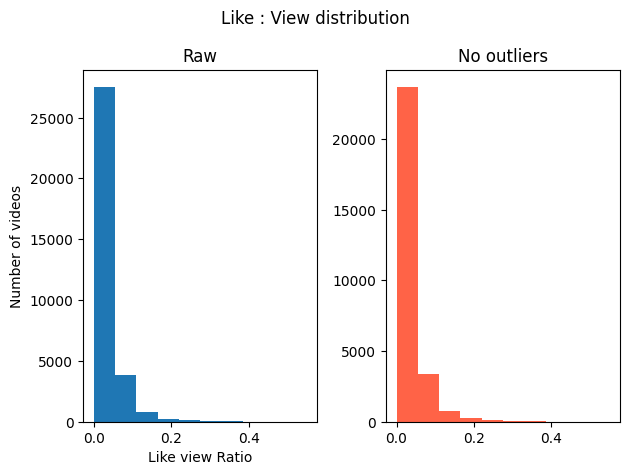

In [58]:
print("----- Like to View Ratio ----")
print("Raw: ")
print_stats(yt_df["likes_view_ratio"])
print("No outliers: ")
print_stats(no_outliers["likes_view_ratio"])

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True)
fig.suptitle("Like : View distribution")
ax1.hist(yt_df["likes_view_ratio"], bins=10)
ax1.set_title("Raw")
ax1.set(ylabel="Number of videos", xlabel="Like view Ratio")
ax2.hist(no_outliers["likes_view_ratio"], bins=10, color="tomato")
ax2.set_title("No outliers")

## Note max ratio is significantly greater than 1. Claude proposed potential API/scraping discrepancies, 
# or YouTube "freezing" the view count as possible explanations.


Number of instances where likes are greater than views: 3
32600
32597
          video_id trending_date  \
6361   ucRulNQsuYQ      26.26.02   
14966  OXFwjgmC6B0      26.26.02   
28883  ucRulNQsuYQ      26.26.02   

                                                   title channel_title  views  \
6361   Gorillaz - The Mountain, The Moon Cave and The...      Gorillaz     10   
14966  Baby Keem, Kendrick Lamar - family ties (Offic...  BabyKeemVEVO      8   
28883  Gorillaz - The Mountain, The Moon Cave and The...      Gorillaz     10   

       likes  dislikes              publish_time  category_id  \
6361   12588         0 2026-02-13 11:27:38+00:00           10   
14966    268         0 2022-08-26 23:38:16+00:00           10   
28883  12631         0 2026-02-13 11:27:38+00:00           10   

                                                    tags  comments  \
6361                                              [none]       624   
14966  Baby|Keem|Kendrick|Lamar|family|ties|(Official...   

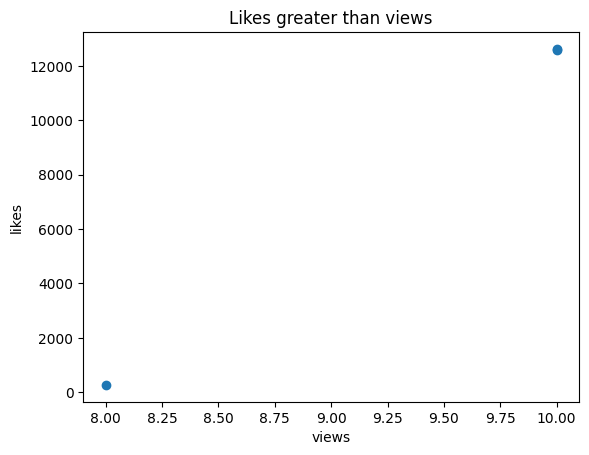

In [47]:
plt.scatter(no_outliers.loc[no_outliers["likes_view_ratio"] > 1, "views"], no_outliers.loc[no_outliers["likes_view_ratio"] > 1, "likes"])
plt.title("Likes greater than views")
plt.xlabel("views")
plt.ylabel("likes")
print("Number of instances where likes are greater than views:", len(no_outliers.loc[no_outliers["likes_view_ratio"] > 1]))

print(len(yt_df))
print(len(yt_df[yt_df["likes_view_ratio"] <= 1]))

print(yt_df[yt_df["likes_view_ratio"] > 1])


----- Like to View Ratio ----
Raw: 
   Max:  0.549353301565691
   Min:  0.0
   Median:  0.02591184176965706
   Mean:  0.03534309358599742
   Standard Dev:  0.0365818324025523
No outliers: 
   Max:  0.549353301565691
   Min:  0.0
   Median:  0.025844582186788412
   Mean:  0.03613739438575327
   Standard Dev:  0.038237845832085796


Text(0.5, 1.0, 'No outliers')

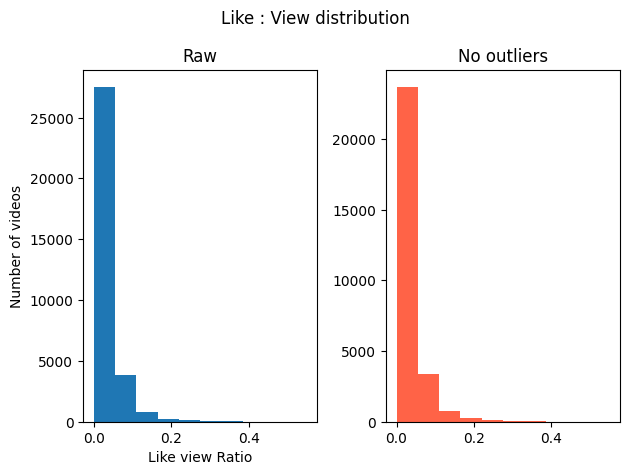

In [57]:
## Based on the videos listed, I suspect it was an issue with the scraping API, as there are two videos with the same
## video ID and different stats.
## Since there's only 3 cases where the like/view ratio is broken, I dropped those.

yt_df = yt_df[yt_df["likes_view_ratio"] <= 1]

## Update no outliers again
no_outliers = yt_df[yt_df['views'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['views'] > (q25 - iqr*1.5)]
print("----- Like to View Ratio ----")
print("Raw: ")
print_stats(yt_df["likes_view_ratio"])
print("No outliers: ")
print_stats(no_outliers["likes_view_ratio"])

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True)
fig.suptitle("Like : View distribution")
ax1.hist(yt_df["likes_view_ratio"], bins=10)
ax1.set_title("Raw")
ax1.set(ylabel="Number of videos", xlabel="Like view Ratio")
ax2.hist(no_outliers["likes_view_ratio"], bins=10, color="tomato")
ax2.set_title("No outliers")


Text(0.5, 1.0, 'Excluding Outliers')

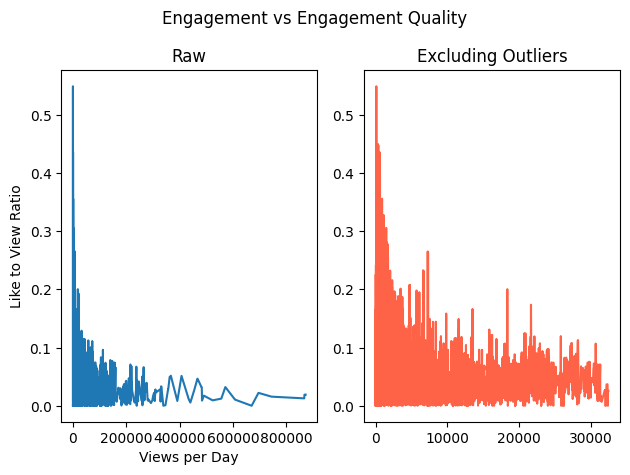

In [55]:
## Plot engagement vs engagement quality

fig, (ax1, ax2) = plt.subplots(1,2, tight_layout=True)
fig.suptitle("Engagement vs Engagement Quality")
ax1.plot(yt_df.sort_values(by="views_per_day")["views_per_day"], yt_df.sort_values(by="views_per_day")["likes_view_ratio"])
ax1.set_title("Raw")
ax1.set(xlabel="Views per Day", ylabel="Like to View Ratio")

ax2.plot(no_outliers.sort_values(by="views_per_day")["views_per_day"], no_outliers.sort_values(by="views_per_day")["likes_view_ratio"], c="tomato")
ax2.set_title("Excluding Outliers")

In [66]:
## Data cleaning for regression tasks

# Remove duplicate videos by id
clean_df = yt_df.drop_duplicates(subset=["video_id"])

# Remove unviewed videos
clean_df = clean_df[clean_df["views"] > 0]

# Clean links from description/title
clean_df["clean_desc"] = clean_df["description"].str.replace(r'https?://\S+', '', regex=True).str.strip()
clean_df["clean_desc"] = clean_df["clean_desc"].str.replace(r'www\.\S+\.com', '', regex=True)
clean_df["clean_desc"] = clean_df["clean_desc"].str.lower()

clean_df.info()

clean_df.to_csv("youtube_data.csv", index=False)

<class 'pandas.DataFrame'>
Index: 21554 entries, 0 to 32505
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   video_id           21554 non-null  str                
 1   trending_date      21554 non-null  str                
 2   title              21554 non-null  str                
 3   channel_title      21553 non-null  str                
 4   views              21554 non-null  int64              
 5   likes              21554 non-null  int64              
 6   dislikes           21554 non-null  int64              
 7   publish_time       21554 non-null  datetime64[us, UTC]
 8   category_id        21554 non-null  int64              
 9   tags               21554 non-null  str                
 10  comments           21554 non-null  int64              
 11  channel_id         21554 non-null  str                
 12  description        18442 non-null  str                
 13  da